In this notebook, we check if data quality metrics actually correlate with a teacher's performance on some benchmarks like Global-MMLU and M-GSM (and maybe M-RewardBench). For now, we'll only investigate the following languages: de, es, ja because they are present in these benchmarks.

In [1]:
import json
import pandas as pd
from typing import Any
from datasets import Dataset, DownloadMode, load_dataset
from huggingface_hub import list_datasets

/Users/ljvmiranda/Developer/multilingual-teacher-eval/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
datasets = [
    ds.id
    for ds in list_datasets(search="details_", author="ljvmiranda921")
    if "quant" not in ds.id
]
print(f"Found {len(datasets)} datasets")
print(datasets)


def parse_outputs(dataset_id: str) -> dict[str, Any]:
    """Parse a dataset ID and output a dataframe containing the relevant fields

    Based from: https://huggingface.co/docs/lighteval/en/saving-and-reading-results
    """
    print(f"Parsing results from dataset {dataset_id}")
    ds = load_dataset(
        dataset_id,
        "results",
        trust_remote_code=True,
        download_mode=DownloadMode.FORCE_REDOWNLOAD,
    )

    # Save all metrics and versions for each task
    metrics = {}
    versions = {}
    for run in ds.keys():
        df = ds[run].to_pandas()
        for task, result in json.loads(df.results.iloc[0]).items():
            if task != "all":
                try:
                    _, benchmark, n_shots = task.split("|")
                except ValueError:
                    benchmark, n_shots = task.split("|")
                if (
                    "global_mmlu_lite" in benchmark
                    or "mgsm_custom" in benchmark
                    or "mrewardbench" in benchmark
                ):
                    metrics[benchmark] = result

        versions.update(json.loads(df.versions.iloc[0]))

    print(f"Found {len(metrics)} tasks!")

    latest_config = json.loads(ds["latest"].to_pandas().config_general.iloc[0])
    model_config = {
        "model_name": latest_config.get("model_name"),
        "model_dtype": latest_config.get("model_dtype"),
        "model_size": latest_config.get("model_size"),
    }

    return {
        "config": model_config,
        "results": metrics,
        "versions": versions,
    }

Found 9 datasets
['ljvmiranda921/details_meta-llama__Llama-3.1-8B-Instruct_private', 'ljvmiranda921/details_CohereLabs__aya-expanse-32b_private', 'ljvmiranda921/details_google__gemma-3-12b-it_private', 'ljvmiranda921/details_google__gemma-3-27b-it_private', 'ljvmiranda921/details_google__gemma-3-4b-it_private', 'ljvmiranda921/details_ibm-granite__granite-4.0-1b_private', 'ljvmiranda921/details_ibm-granite__granite-4.0-micro_private', 'ljvmiranda921/details_mistralai__Mistral-Small-24B-Instruct-2501_private', 'ljvmiranda921/details_meta-llama__Llama-3.1-70B-Instruct_private']


In [3]:
parsed_results = pd.DataFrame([parse_outputs(dataset) for dataset in datasets])

Parsing results from dataset ljvmiranda921/details_meta-llama__Llama-3.1-8B-Instruct_private


Generating 2025_12_06T15_27_45.049297 split: 1 examples [00:00, 211.87 examples/s]
Generating 2025_12_06T15_39_03.987641 split: 1 examples [00:00, 587.85 examples/s]
Generating 2025_12_06T16_00_42.616952 split: 1 examples [00:00, 694.88 examples/s]
Generating 2025_12_07T22_50_41.708307 split: 1 examples [00:00, 625.36 examples/s]
Generating 2025_12_07T22_51_15.845985 split: 1 examples [00:00, 612.66 examples/s]
Generating 2025_12_11T23_39_45.389492 split: 1 examples [00:00, 716.24 examples/s]
Generating 2025_12_11T23_54_44.866733 split: 1 examples [00:00, 810.96 examples/s]
Generating 2025_12_11T23_54_59.258932 split: 1 examples [00:00, 653.11 examples/s]
Generating 2025_12_12T09_48_17.706312 split: 1 examples [00:00, 815.06 examples/s]
Generating 2025_12_12T09_58_18.944391 split: 1 examples [00:00, 633.01 examples/s]
Generating 2025_12_12T10_03_38.247237 split: 1 examples [00:00, 787.96 examples/s]
Generating 2025_12_12T11_17_27.640735 split: 1 examples [00:00, 807.84 examples/s]
Gene

Found 9 tasks!
Parsing results from dataset ljvmiranda921/details_CohereLabs__aya-expanse-32b_private


Generating 2025_12_07T23_03_34.779727 split: 1 examples [00:00, 379.37 examples/s]
Generating 2025_12_07T23_04_13.726707 split: 1 examples [00:00, 448.88 examples/s]
Generating 2025_12_07T23_04_31.110621 split: 1 examples [00:00, 603.06 examples/s]
Generating 2025_12_07T23_04_35.426313 split: 1 examples [00:00, 741.31 examples/s]
Generating 2025_12_07T23_09_35.561596 split: 1 examples [00:00, 596.63 examples/s]
Generating 2025_12_07T23_11_46.667872 split: 1 examples [00:00, 538.56 examples/s]
Generating 2025_12_11T23_56_26.942329 split: 1 examples [00:00, 709.22 examples/s]
Generating 2025_12_11T23_56_27.732668 split: 1 examples [00:00, 637.04 examples/s]
Generating 2025_12_12T10_05_52.166106 split: 1 examples [00:00, 293.68 examples/s]
Generating 2025_12_12T10_06_15.342136 split: 1 examples [00:00, 668.41 examples/s]
Generating 2025_12_12T11_17_57.904831 split: 1 examples [00:00, 405.83 examples/s]
Generating 2025_12_12T15_11_18.363515 split: 1 examples [00:00, 604.63 examples/s]
Gene

Found 9 tasks!
Parsing results from dataset ljvmiranda921/details_google__gemma-3-12b-it_private


...

Found 9 tasks!
Parsing results from dataset ljvmiranda921/details_mistralai__Mistral-Small-24B-Instruct-2501_private


Generating latest split: 100%|██████████| 1/1 [00:00<00:00, 610.79 examples/s]


Found 3 tasks!
Parsing results from dataset ljvmiranda921/details_meta-llama__Llama-3.1-70B-Instruct_private


Generating latest split: 100%|██████████| 1/1 [00:00<00:00, 789.74 examples/s]

Found 6 tasks!


In [6]:
parsed_results.iloc[0].results

{'global_mmlu_lite:de': {'acc': 0.42, 'acc_stderr': 0.02470883072485368},
 'global_mmlu_lite:es': {'acc': 0.505, 'acc_stderr': 0.02503005711936146},
 'global_mmlu_lite:ja': {'acc': 0.5, 'acc_stderr': 0.02503130871608794},
 'mgsm_custom:de': {'extractive_match': 0.16,
  'extractive_match_stderr': 0.023232714782060643},
 'mgsm_custom:es': {'extractive_match': 0.136,
  'extractive_match_stderr': 0.021723342617052062},
 'mgsm_custom:ja': {'extractive_match': 0.124,
  'extractive_match_stderr': 0.02088638225867326},
 'mrewardbench_mcf:de': {'acc_norm_token': 0.4956430812129662,
  'acc_norm_token_stderr': 0.009336066618704135,
  'weighted_acc': 0.4879259246080536,
  'weighted_acc_stderr': 0.0003615563111154185,
  'weighted_acc_chat': 0.5,
  'weighted_acc_chat_stderr': 0.0009745183480258166,
  'weighted_acc_chat_hard': 0.4520884520884521,
  'weighted_acc_chat_hard_stderr': 0.000794774848192557,
  'weighted_acc_safety': 0.49320652173913043,
  'weighted_acc_safety_stderr': 0.0005801180065696243

In [4]:
parsed_results

,config,results,versions
0,{'model_name': 'meta-llama/Llama-3.1-8B-Instru...,"{'global_mmlu_lite:de': {'acc': 0.42, 'acc_std...","{'lighteval|global_mmlu_lite:de|0': 0, 'lighte..."
1,"{'model_name': 'CohereLabs/aya-expanse-32b', '...","{'global_mmlu_lite:es': {'acc': 0.5625, 'acc_s...","{'lighteval|mgsm:de|0': 0, 'lighteval|global_m..."
2,"{'model_name': 'google/gemma-3-12b-it', 'model...","{'global_mmlu_lite:es': {'acc': 0.5675, 'acc_s...","{'lighteval|global_mmlu_lite:es|0': 0, 'lighte..."
3,"{'model_name': 'google/gemma-3-27b-it', 'model...","{'global_mmlu_lite:ja': {'acc': 0.5725, 'acc_s...","{'lighteval|global_mmlu_lite:ja|0': 0, 'lighte..."
4,"{'model_name': 'google/gemma-3-4b-it', 'model_...","{'global_mmlu_lite:de': {'acc': 0.4775, 'acc_s...","{'lighteval|global_mmlu_lite:de|0': 0, 'lighte..."
5,"{'model_name': 'ibm-granite/granite-4.0-1b', '...","{'global_mmlu_lite:es': {'acc': 0.48, 'acc_std...","{'lighteval|global_mmlu_lite:es|0': 0, 'lighte..."
6,{'model_name': 'ibm-granite/granite-4.0-micro'...,"{'global_mmlu_lite:es': {'acc': 0.59, 'acc_std...","{'lighteval|global_mmlu_lite:es|0': 0, 'lighte..."
7,{'model_name': 'mistralai/Mistral-Small-24B-In...,"{'global_mmlu_lite:de': {'acc': 0.57, 'acc_std...","{'lighteval|global_mmlu_lite:de|0': 0, 'lighte..."
8,{'model_name': 'meta-llama/Llama-3.1-70B-Instr...,"{'mgsm_custom:de': {'extractive_match': 0.3, '...",{}


Now let's analyze if there's a correlation between teacher model performance on Global-MMLU Lite and the quality of synthetic data they generate for German, Japanese, and Spanish.

In [6]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

sys.path.append("../../scripts/")
from analysis.model_info import MODEL_INFORMATION
from analysis import plot_theme

# Load plot parameters
plot_params = plot_theme.PLOT_PARAMS.copy()
plt.rcParams.update(plot_params)

In [7]:
# Load data quality metrics
df_quality = pd.read_json(
    "../../notebooks/2025-11-24-data-quality-metrics/data/compiled_intrinsic_metrics.jsonl",
    orient="records",
    lines=True,
)


def calculate_quality_score(df):
    """Calculate an aggregate quality score from intrinsic metrics using z-score normalization.

    Each metric is standardized (mean=0, std=1) and then averaged. This approach:
    - Handles extreme outliers automatically
    - Gives equal weight to each metric in terms of variance
    - Incorporates all 4 metrics: prompts_distinct_ri, responses_distinct_ri,
      rubric_score, and perplexity (log-transformed and inverted)
    """
    data = np.column_stack(
        [
            df["prompts_distinct_ri"],
            df["responses_distinct_ri"],
            df["rubric_score"],
            -np.log1p(df["perplexity"]),
        ]
    )

    # Standardize and average
    scaler = StandardScaler()
    normalized = scaler.fit_transform(data)
    quality_score = normalized.mean(axis=1)

    return quality_score


# Calculate quality score
df_quality["quality_score"] = calculate_quality_score(df_quality)

# Filter for languages we're interested in
df_quality_filtered = df_quality[df_quality["language"].isin(["de", "es", "ja"])].copy()

df_quality_filtered.head()

,language,model,prompts_distinct_ri,responses_distinct_ri,rubric_score,perplexity,quality_score
20,de,CohereLabs/aya-expanse-32b,0.700103,0.901674,4.1400,3.441957,0.445365
21,de,cohere-command-a,0.729790,0.889303,4.2353,3.586949,0.585925
22,de,google/gemma-3-12b-it,0.751085,0.898606,4.2028,4.060759,0.811696
23,de,google/gemma-3-27b-it,0.730997,0.897766,4.2601,3.960716,0.675951
24,de,google/gemma-3-4b-it,0.744396,0.897925,4.1030,3.963183,0.718975


In [8]:
# Extract MMLU-Lite scores from MODEL_INFORMATION
mmlu_scores = []

for model_info in MODEL_INFORMATION:
    if model_info.benchmark_scores:
        for benchmark_key, scores in model_info.benchmark_scores.items():
            if "global_mmlu_lite" in benchmark_key:
                # Extract language from benchmark key (e.g., "global_mmlu_lite:de" -> "de")
                lang = benchmark_key.split(":")[-1]
                mmlu_scores.append(
                    {
                        "model": model_info.name,
                        "language": lang,
                        "mmlu_acc": scores["acc"],
                        "mmlu_stderr": scores["acc_stderr"],
                    }
                )

df_mmlu = pd.DataFrame(mmlu_scores)

# Merge MMLU scores with quality metrics
df_merged = df_quality_filtered.merge(df_mmlu, on=["model", "language"], how="inner")

print(f"Merged {len(df_merged)} model-language pairs")
df_merged[["model", "language", "mmlu_acc", "quality_score"]].sort_values(
    "mmlu_acc", ascending=False
)

Merged 21 model-language pairs


,model,language,mmlu_acc,quality_score
0,CohereLabs/aya-expanse-32b,de,0.6425,0.445365
14,CohereLabs/aya-expanse-32b,ja,0.6350,0.418599
12,ibm-granite/granite-4.0-micro,es,0.5900,0.362199
9,google/gemma-3-27b-it,es,0.5825,0.992086
1,google/gemma-3-12b-it,de,0.5800,0.811696
16,google/gemma-3-27b-it,ja,0.5725,0.574780
8,google/gemma-3-12b-it,es,0.5675,0.863697
7,CohereLabs/aya-expanse-32b,es,0.5625,0.556340
5,ibm-granite/granite-4.0-micro,de,0.5400,0.361800
2,google/gemma-3-27b-it,de,0.5250,0.675951


In [9]:
# Calculate correlation for each language
from scipy.stats import pearsonr, spearmanr

correlations = {}
for lang in ["de", "es", "ja"]:
    df_lang = df_merged[df_merged["language"] == lang]

    pearson_corr, pearson_p = pearsonr(df_lang["mmlu_acc"], df_lang["quality_score"])
    spearman_corr, spearman_p = spearmanr(df_lang["mmlu_acc"], df_lang["quality_score"])

    correlations[lang] = {
        "pearson": pearson_corr,
        "pearson_p": pearson_p,
        "spearman": spearman_corr,
        "spearman_p": spearman_p,
    }

Loading model family logos...
✓ Loaded Aya logo from logos/aya.png
✓ Loaded Gemma logo from logos/google.png
✓ Loaded Granite logo from logos/ibm.png
✓ Loaded Llama logo from logos/meta.png


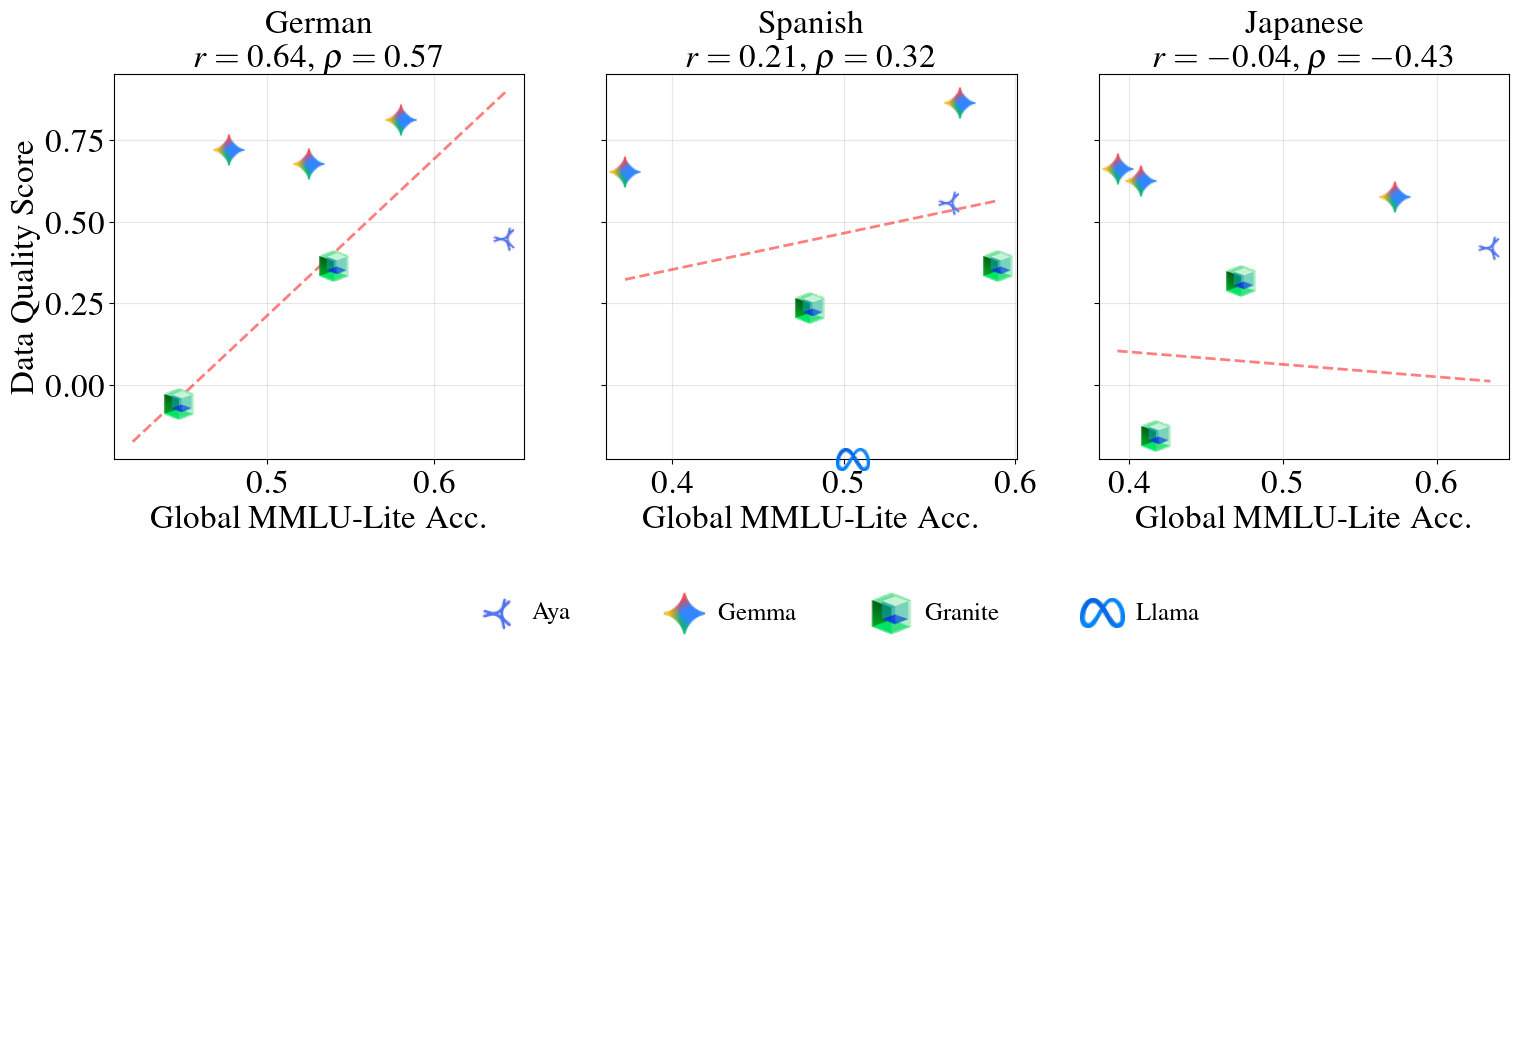

In [35]:
# Create scatter plots for each language
from analysis.plot_theme import COLORS
from pathlib import Path
from matplotlib.offsetbox import OffsetImage, AnnotationBbox, HPacker, TextArea
from PIL import Image

# Create figures directory if it doesn't exist
figures_dir = Path("figures")
figures_dir.mkdir(exist_ok=True)

# Create logos directory
logos_dir = Path("logos")


# Load logo helper function
def load_logo_image(filepath, target_size=30):
    """Load a PNG logo from file and resize to fixed pixel size"""
    try:
        img = Image.open(filepath)

        # Convert to RGBA to preserve transparency
        if img.mode != "RGBA":
            img = img.convert("RGBA")

        # Resize maintaining aspect ratio
        img.thumbnail((target_size, target_size), Image.Resampling.LANCZOS)

        return OffsetImage(img, zoom=0.8)
    except Exception as e:
        print(f"Failed to load {filepath}: {e}")
        return None


# Map families to logo files
family_logo_map = {
    "Aya": logos_dir / "aya.png",
    "Gemma": logos_dir / "google.png",
    "Granite": logos_dir / "ibm.png",
    "Llama": logos_dir / "meta.png",
}

# Pre-load all logos
print("Loading model family logos...")
logo_images = {}
for family, filepath in family_logo_map.items():
    if filepath.exists():
        img = load_logo_image(filepath, target_size=30)
        if img:
            logo_images[family] = img
            print(f"✓ Loaded {family} logo from {filepath}")
    else:
        print(f"✗ Logo not found: {filepath}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

language_names = {
    "de": "German",
    "es": "Spanish",
    "ja": "Japanese",
}

languages = ["de", "es", "ja"]

for idx, (lang, ax) in enumerate(zip(languages, axes)):
    df_lang = df_merged[df_merged["language"] == lang].copy()

    # Add model family information for coloring
    model_info_df = pd.DataFrame([m.model_dump() for m in MODEL_INFORMATION])
    df_lang = df_lang.merge(
        model_info_df[["name", "model_family"]],
        left_on="model",
        right_on="name",
        how="left",
    )

    # Define colors for model families
    family_colors = {
        "Aya": COLORS["warm_blue"],
        "Gemma": COLORS["warm_crest"],
        "Granite": COLORS["heritage"],
        "Llama": COLORS["slate"],
    }

    # Plot each model family with logos
    for family in df_lang["model_family"].unique():
        family_data = df_lang[df_lang["model_family"] == family]

        for _, row in family_data.iterrows():
            x_pos = row["mmlu_acc"]
            y_pos = row["quality_score"]

            ab = AnnotationBbox(
                logo_images[family],
                (x_pos, y_pos),
                xycoords="data",
                frameon=False,
                box_alignment=(0.5, 0.5),
                zorder=3,
                pad=0,
            )
            ax.add_artist(ab)

            # if family in logo_images:
            #     # Add logo as image
            #     ab = AnnotationBbox(
            #         logo_images[family],
            #         (x_pos, y_pos),
            #         xycoords="data",
            #         frameon=False,
            #         box_alignment=(0.5, 0.5),
            #         zorder=3,
            #         pad=0,
            #     )
            #     ax.add_artist(ab)
            # else:
            # Fallback to regular marker if logo not available
            # ax.scatter(
            #     x_pos,
            #     y_pos,
            #     color=family_colors.get(family, "#2E3440"),
            #     s=150,
            #     alpha=0.7,
            #     edgecolors="black",
            #     linewidth=1.5,
            #     label=family if idx == 2 else "",
            #     zorder=3,
            # )

    # Add linear regression line
    from scipy.stats import linregress

    slope, intercept, r_value, p_value, std_err = linregress(
        df_lang["mmlu_acc"], df_lang["quality_score"]
    )
    x_line = np.linspace(df_lang["mmlu_acc"].min(), df_lang["mmlu_acc"].max(), 100)
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, "r--", alpha=0.5, linewidth=2, zorder=2)

    # Add correlation info to title
    pearson_corr = correlations[lang]["pearson"]
    spearman_corr = correlations[lang]["spearman"]
    ax.set_title(
        f"{language_names[lang]}\n$r={pearson_corr:.2f}$, $\\rho={spearman_corr:.2f}$"
    )

    ax.set_xlabel("Global MMLU-Lite Acc.")
    if idx == 0:
        ax.set_ylabel("Data Quality Score")

    ax.grid(True, alpha=0.3, zorder=1)

# Create custom legend with logos at the bottom
legend_families = ["Aya", "Gemma", "Granite", "Llama"]

for family in legend_families:
    if family in logo_images:
        # Load a bigger version for legend
        legend_img = load_logo_image(family_logo_map[family], target_size=40)
        if legend_img:
            # Create a text area with logo for legend
            text_box = TextArea(family, textprops=dict(size=18))
            h_packer = HPacker(
                children=[legend_img, text_box], align="center", pad=0, sep=8
            )

            # Add to bottom center - moved lower with -0.20
            ab = AnnotationBbox(
                h_packer,
                (-0.2 + 0.5 * legend_families.index(family), -0.40),
                xycoords="axes fraction",
                frameon=False,
                box_alignment=(0.5, 0.5),
            )
            axes[1].add_artist(ab)

# plt.tight_layout()
fig.savefig(
    figures_dir / "mmlu_vs_quality_correlation.png", dpi=300, bbox_inches="tight"
)

plt.show()

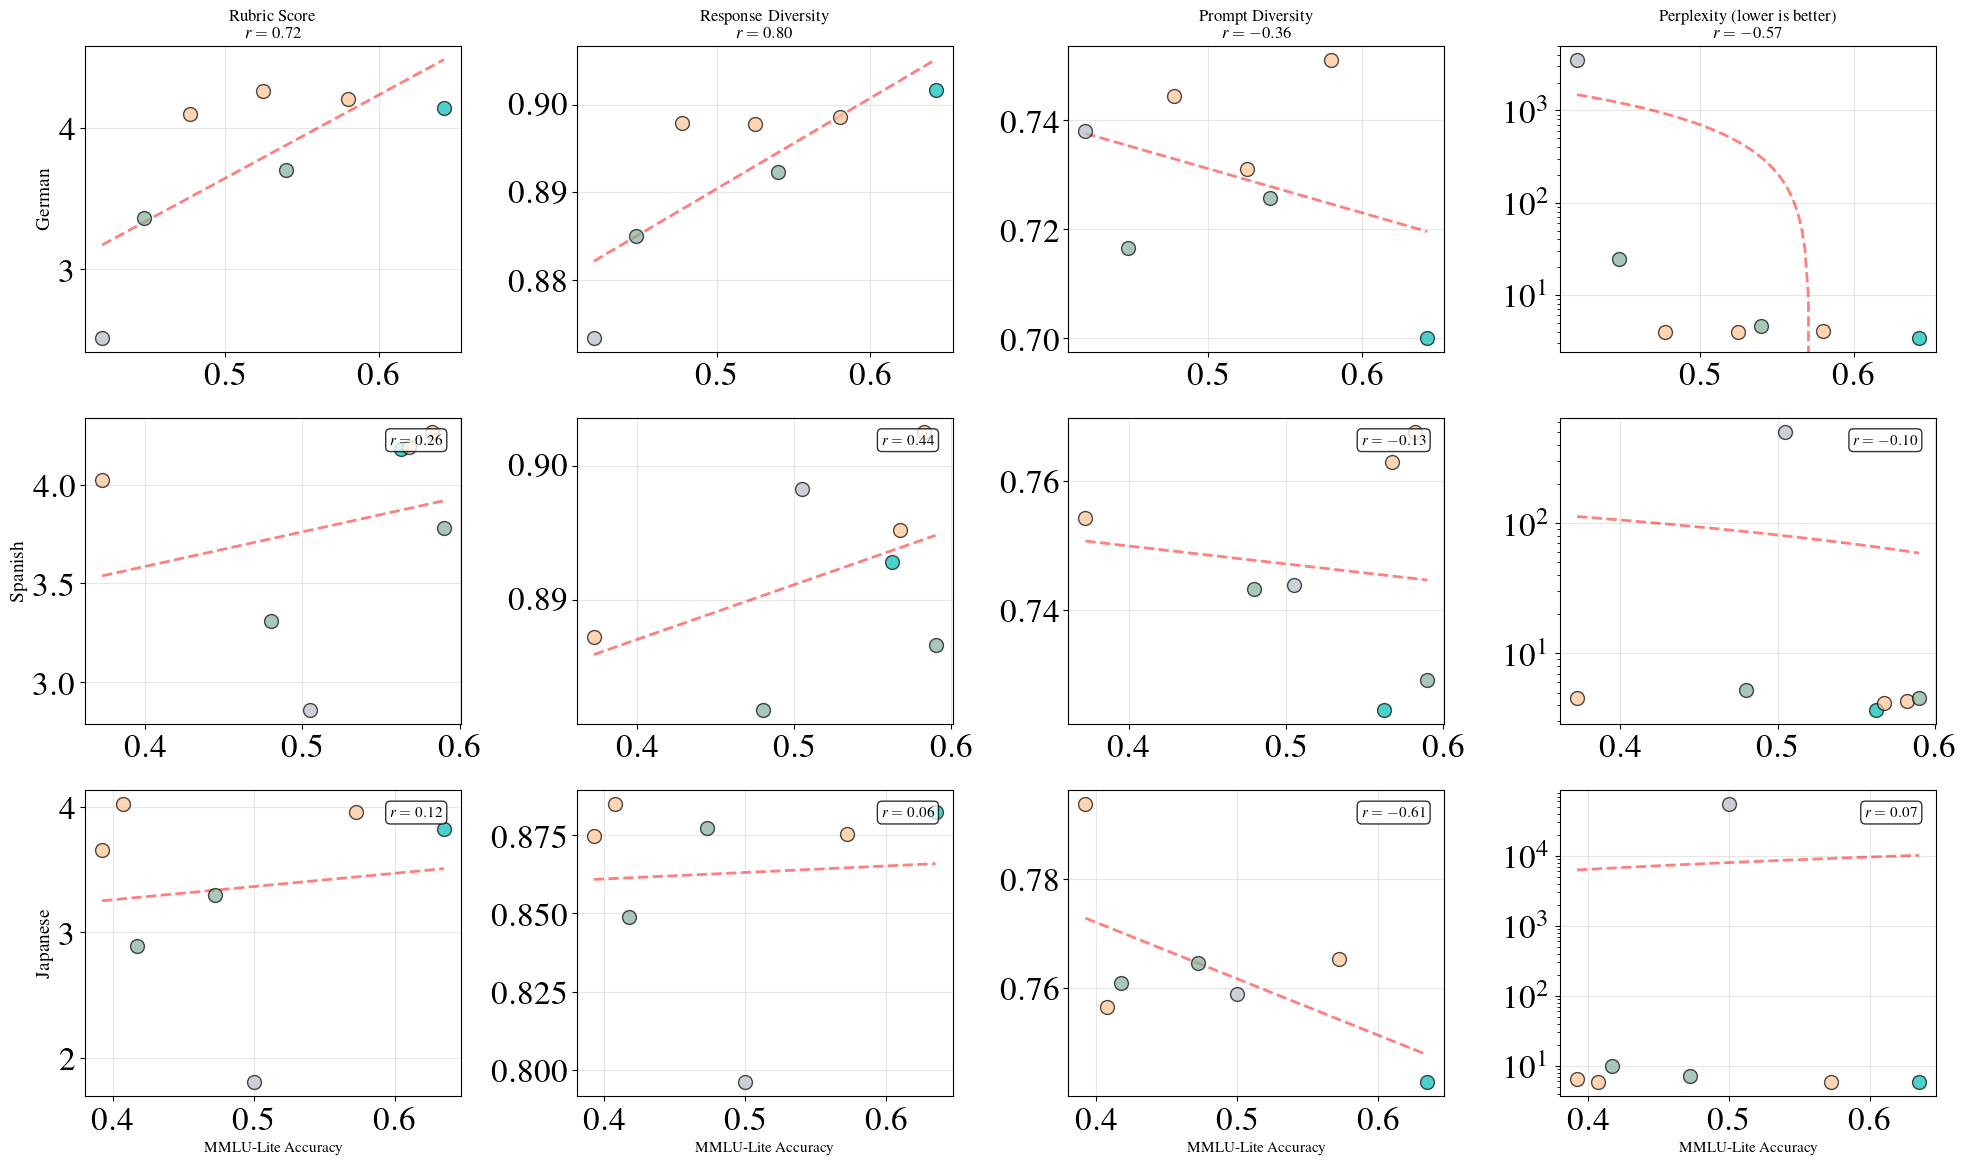

In [ ]:
# Analyze correlation with individual quality metrics
fig, axes = plt.subplots(3, 4, figsize=(20, 12))

quality_metrics = {
    "rubric_score": "Rubric Score",
    "responses_distinct_ri": "Response Diversity",
    "prompts_distinct_ri": "Prompt Diversity",
    "perplexity": "Perplexity (lower is better)",
}

for row_idx, lang in enumerate(["de", "es", "ja"]):
    df_lang = df_merged[df_merged["language"] == lang].copy()

    # Add model family information
    model_info_df = pd.DataFrame([m.model_dump() for m in MODEL_INFORMATION])
    df_lang = df_lang.merge(
        model_info_df[["name", "model_family"]],
        left_on="model",
        right_on="name",
        how="left",
    )

    for col_idx, (metric, metric_name) in enumerate(quality_metrics.items()):
        ax = axes[row_idx, col_idx]

        # Plot each model family
        for family in df_lang["model_family"].unique():
            family_data = df_lang[df_lang["model_family"] == family]
            ax.scatter(
                family_data["mmlu_acc"],
                family_data[metric],
                color=family_colors.get(family, "#2E3440"),
                s=100,
                alpha=0.7,
                edgecolors="black",
                linewidth=1.0,
                zorder=3,
            )

        # Calculate correlation
        corr, p_val = pearsonr(df_lang["mmlu_acc"], df_lang[metric])

        # Add regression line
        slope, intercept, _, _, _ = linregress(df_lang["mmlu_acc"], df_lang[metric])
        x_line = np.linspace(df_lang["mmlu_acc"].min(), df_lang["mmlu_acc"].max(), 100)
        y_line = slope * x_line + intercept
        ax.plot(x_line, y_line, "r--", alpha=0.5, linewidth=2, zorder=2)

        # Labels
        if row_idx == 0:
            ax.set_title(f"{metric_name}\n$r={corr:.2f}$", fontsize=12)
        else:
            ax.text(
                0.95,
                0.95,
                f"$r={corr:.2f}$",
                transform=ax.transAxes,
                ha="right",
                va="top",
                fontsize=11,
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
            )

        if col_idx == 0:
            ax.set_ylabel(f"{language_names[lang]}", fontsize=14, fontweight="bold")

        if row_idx == 2:
            ax.set_xlabel("MMLU-Lite Accuracy", fontsize=11)

        ax.grid(True, alpha=0.3, zorder=1)

        # Use log scale for perplexity
        if metric == "perplexity":
            ax.set_yscale("log")

plt.tight_layout()
# fig.savefig(
#    figures_dir / "mmlu_vs_individual_metrics.png", dpi=300, bbox_inches="tight"
# )

plt.show()